# M3 — KPI Dashboard: Factory State Overview

**Synthetic data only — not real production data.**  
This notebook visualises five key performance indicators derived from the synthetic
re-entrant production line generated in M2.  
All statistics are restricted to the **steady-state window** (warm-up excluded).
No bottleneck conclusions are drawn here; that analysis is reserved for M4.

| Parameter | Value |
|-----------|-------|
| Simulation horizon | 1 440 h (60 days) |
| Warm-up period | 144 h (6 days) |
| Steady-state window | 144 – 1 440 h |
| Stations | CLEAN, FURNACE (batch), DEPO, LITHO (re-entrant), ETCH, IMPLANT, METRO |
| Tools per station | 2 (FURNACE: 2 tools × 4-lot batches) |
| Unit of flow | 1 lot = one 25-wafer carrier (FOUP) |

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make src/ importable from the notebooks/ directory
sys.path.insert(0, str(Path("../src")))
from kpi.kpi_metrics import (
    cycle_time_stats,
    x_factor,
    daily_median_ct,
    daily_throughput,
    station_utilization,
    wip_timeseries,
)

print("Imports OK")

Imports OK


C:\Users\User\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
DATA_DIR = Path("../data/synthetic")

event_log = pd.read_csv(DATA_DIR / "event_log.csv")
lifecycle  = pd.read_csv(DATA_DIR / "lot_lifecycle.csv")

with open(DATA_DIR / "metadata.json") as f:
    meta = json.load(f)

T_WARMUP  = meta["warmup_hours"]    # 144
T_HORIZON = meta["horizon_hours"]   # 1440
STATIONS  = meta["stations"]         # per-station n_tools / batch_size (from metadata)

print(f"event_log  : {event_log.shape[0]:,} rows | {event_log.shape[1]} columns")
print(f"lifecycle  : {lifecycle.shape[0]:,} rows | {lifecycle.shape[1]} columns")
print(f"T_WARMUP   : {T_WARMUP} h")
print(f"T_HORIZON  : {T_HORIZON} h")
print("CAPACITY   : per-station n_tools x batch_size "
      f"(FURNACE {STATIONS['FURNACE']['n_tools']} tools x "
      f"{STATIONS['FURNACE']['batch_size']}-lot batches)")

event_log  : 11,432 rows | 7 columns
lifecycle  : 1,429 rows | 3 columns
T_WARMUP   : 144 h
T_HORIZON  : 1440 h
CAPACITY   : per-station n_tools x batch_size (FURNACE 2 tools x 4-lot batches)


---
## Chart 1 — Daily Output (Throughput Trend)

**What this chart shows:**  
The number of lots completed each simulation day during the steady-state window.
A stable, flat bar pattern indicates the line is running at its designed throughput rate.
Sustained downward or upward deviation from the expected daily output (dashed reference line)
would signal a capacity change worth investigating.

**How to read it:**  
Each bar = one calendar day of simulation time. The dashed orange line marks the theoretical
daily output implied by the generator's arrival rate and utilization targets
(≈ 0.987 lots/h × 24 h ≈ 23.7 lots/day). Natural day-to-day variability from Poisson arrivals
and lognormal processing times is expected.

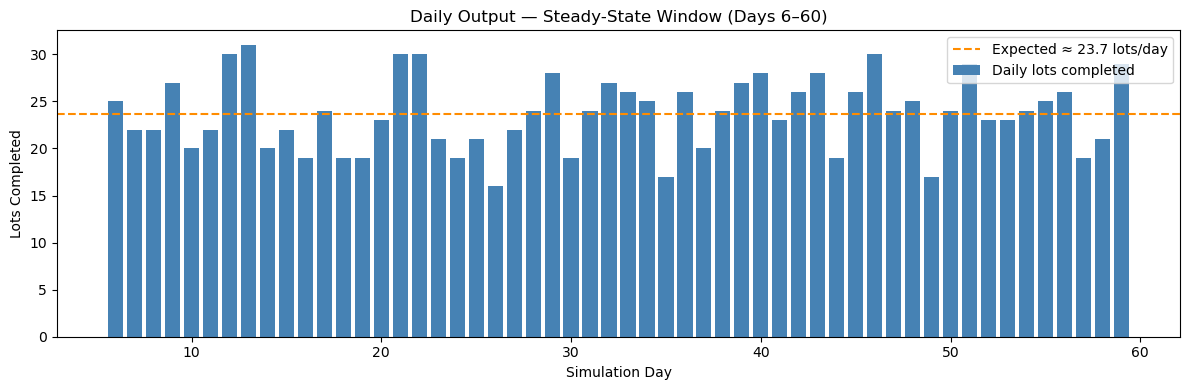

In [3]:
throughput_df = daily_throughput(lifecycle, T_WARMUP, T_HORIZON)
expected_daily = meta["validation"]["throughput_per_hour"] * 24

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(throughput_df["day"], throughput_df["count"], color="steelblue", label="Daily lots completed")
ax.axhline(expected_daily, color="darkorange", linestyle="--",
           label=f"Expected ≈ {expected_daily:.1f} lots/day")
ax.set_title("Daily Output — Steady-State Window (Days 6–60)")
ax.set_xlabel("Simulation Day")
ax.set_ylabel("Lots Completed")
ax.legend()
plt.tight_layout()
plt.show()

---
## Chart 2 — WIP over Time

**What this chart shows:**  
The number of lots inside the line at every point in time, constructed as a step function
from arrival events (+1) and completion events (−1).  
The full 60-day horizon is shown so the warm-up transient is visible.

**How to read it:**  
WIP rises steeply in the first 6 days as lots enter but few have yet completed (warm-up phase,
left of the vertical dashed line). After the warm-up, WIP oscillates around its steady-state
mean (dashed horizontal line ≈ 11.3 lots, from measured simulation data).  
Little's Law connects WIP, throughput, and cycle time: WIP = throughput × cycle time.  
Persistent upward drift in WIP would indicate growing queue build-up.

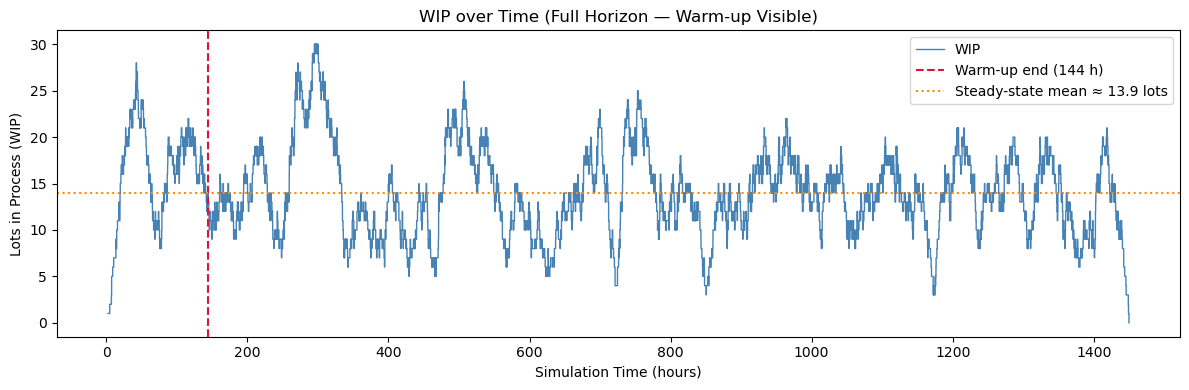

In [4]:
times, wip = wip_timeseries(lifecycle)
wip_measured = meta["validation"]["wip_measured"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.step(times, wip, where="post", color="steelblue", linewidth=1, label="WIP")
ax.axvline(T_WARMUP, color="crimson", linestyle="--",
           label=f"Warm-up end ({T_WARMUP} h)")
ax.axhline(wip_measured, color="darkorange", linestyle=":",
           label=f"Steady-state mean ≈ {wip_measured:.1f} lots")
ax.set_title("WIP over Time (Full Horizon — Warm-up Visible)")
ax.set_xlabel("Simulation Time (hours)")
ax.set_ylabel("Lots in Process (WIP)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Chart 3 — Station Utilization

**What this chart shows:**  
How much of each station's available capacity is consumed during the steady-state window,
expressed as a fraction (0 = idle, 1 = fully busy).  
Utilization = total busy time ÷ (n_tools × batch_size × window length) — **slot utilization** —
with operations overlapping the window boundary clipped proportionally.
For serial tools this is the classic busy-tool fraction; for the batch FURNACE each
member lot carries the run duration, so the ratio measures used lot-slots (the fab
capacity view of batch tools).

**How to read it:**  
Blue bars are empirical (computed from the event log). Orange markers show the theoretical
design targets from `metadata.json`. Close agreement confirms the simulation ran as designed.
The dashed line at 0.85 marks LITHO's design utilization — the highest in the line.
A station approaching 1.0 has little slack; minor demand increases will cause queue growth there.

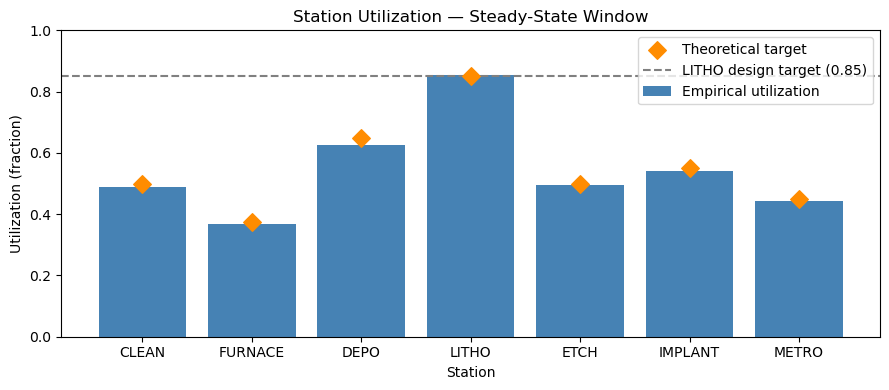

In [5]:
util_df = station_utilization(event_log, T_WARMUP, T_HORIZON, STATIONS)
theo_util = meta["theoretical_utilization"]
theo_vals = [theo_util.get(s, float("nan")) for s in util_df["station"]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(util_df["station"], util_df["utilization"], color="steelblue", label="Empirical utilization")
ax.scatter(util_df["station"], theo_vals, marker="D", color="darkorange",
           zorder=5, s=80, label="Theoretical target")
ax.axhline(0.85, color="gray", linestyle="--", label="LITHO design target (0.85)")
ax.set_ylim(0, 1.0)
ax.set_title("Station Utilization — Steady-State Window")
ax.set_xlabel("Station")
ax.set_ylabel("Utilization (fraction)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Chart 4 — Cycle Time Distribution

**What this chart shows:**  
The distribution of end-to-end cycle times (arrival → completion) for all lots that
completed during the steady-state window. Cycle time = total time a lot spends in the
line, including both queueing and processing at every station.

**How to read it:**  
A right-skewed distribution is expected in a queueing system: most lots finish near the
median, but a long tail exists for lots that waited behind congestion bursts.
The green line marks the **median** — the typical experience. The red line marks the
**P90** — 90% of lots complete faster than this. The gap between median and P90 indicates
how heavy the tail is.

Steady-state lots: 1280
Median CT : 13.53 h
P90 CT    : 19.30 h
Mean CT   : 14.14 h  (metadata: 14.14 h)


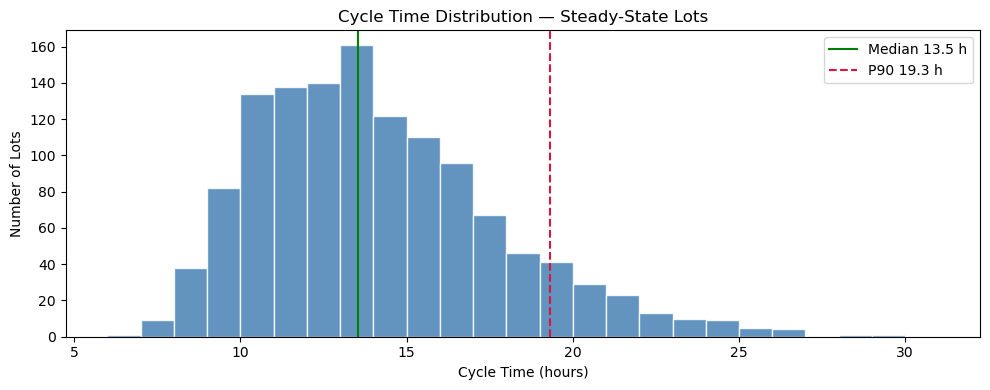

In [6]:
ct_series, ct_median, ct_p90 = cycle_time_stats(lifecycle, T_WARMUP, T_HORIZON)

bins = np.arange(int(ct_series.min()), ct_series.max() + 2, 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ct_series, bins=bins, color="steelblue", alpha=0.85, edgecolor="white")
ax.axvline(ct_median, color="green", linewidth=1.5, label=f"Median {ct_median:.1f} h")
ax.axvline(ct_p90, color="crimson", linewidth=1.5, linestyle="--", label=f"P90 {ct_p90:.1f} h")
ax.set_title("Cycle Time Distribution — Steady-State Lots")
ax.set_xlabel("Cycle Time (hours)")
ax.set_ylabel("Number of Lots")
ax.legend()
plt.tight_layout()

print(f"Steady-state lots: {len(ct_series)}")
print(f"Median CT : {ct_median:.2f} h")
print(f"P90 CT    : {ct_p90:.2f} h")
print(f"Mean CT   : {ct_series.mean():.2f} h  (metadata: {meta['validation']['avg_cycle_time_hours']:.2f} h)")

plt.show()

---
## Chart 5 — Daily Median Cycle Time over Time

**What this chart shows:**  
How the median cycle time evolves day by day across the steady-state window.
This surfaces gradual drift that a single-number summary would hide.

**How to read it:**  
Each point is the median cycle time of all lots that completed on that simulation day.
The dashed orange line marks the overall average cycle time from `metadata.json` (≈ 11.45 h),
providing a stable reference.  
A flat, random scatter around the reference indicates a stationary process.
A rising trend would indicate queue accumulation over time.
Day-to-day noise is expected from Poisson arrivals; interpret only multi-day trends.

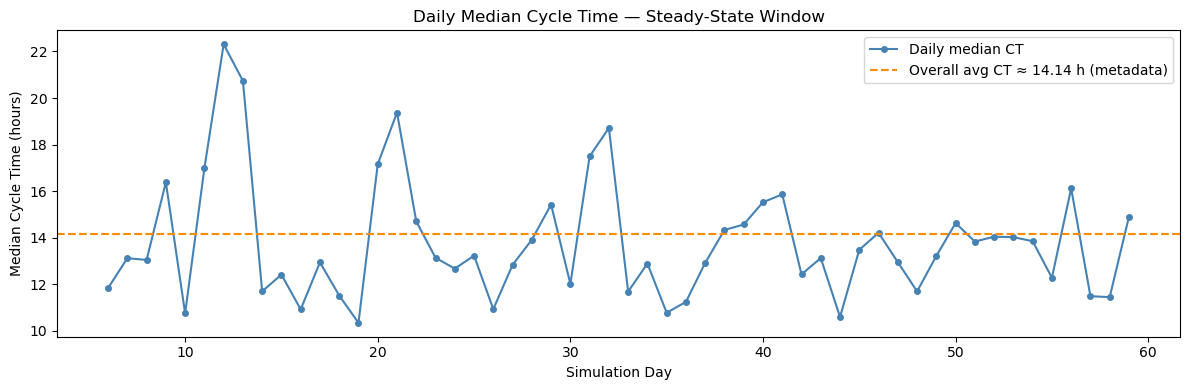

In [7]:
dct_df = daily_median_ct(lifecycle, T_WARMUP, T_HORIZON)
avg_ct_meta = meta["validation"]["avg_cycle_time_hours"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dct_df["day"], dct_df["median_ct"], color="steelblue", linewidth=1.5,
        marker="o", markersize=4, label="Daily median CT")
ax.axhline(avg_ct_meta, color="darkorange", linestyle="--",
           label=f"Overall avg CT ≈ {avg_ct_meta:.2f} h (metadata)")
ax.set_title("Daily Median Cycle Time — Steady-State Window")
ax.set_xlabel("Simulation Day")
ax.set_ylabel("Median Cycle Time (hours)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Chart 6 — X-factor (cycle time ÷ raw process time)

**What this chart shows:**
The **X-factor** is the headline fab flow metric: how many times longer a lot's
cycle time is than its raw processing time. X = 1 would mean zero queueing; the
excess above 1 is time spent waiting. Fabs track this per lot and per period —
it converts "cycle time is long" into "how much of it is queueing".

**How to read it:**
The distribution is over lots completed in the steady-state window. The median
tells you the typical queueing burden; the p90 tail shows how bad the unlucky
lots get. On this stylized 7-station line the X-factor is naturally lower than
a real fab's (hundreds of steps, tighter loading, batching/setup effects
compound); the metric and its reading are what transfer.

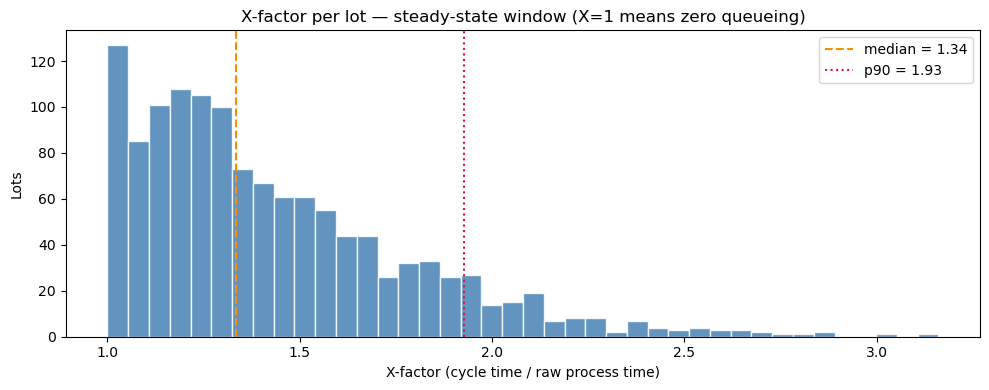

X-factor median : 1.34
X-factor p90    : 1.93


In [8]:
x_series, x_med, x_p90 = x_factor(event_log, lifecycle, T_WARMUP, T_HORIZON)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(x_series, bins=40, color="steelblue", alpha=0.85, edgecolor="white")
ax.axvline(x_med, color="darkorange", linestyle="--",
           label=f"median = {x_med:.2f}")
ax.axvline(x_p90, color="crimson", linestyle=":",
           label=f"p90 = {x_p90:.2f}")
ax.set_title("X-factor per lot — steady-state window (X=1 means zero queueing)")
ax.set_xlabel("X-factor (cycle time / raw process time)")
ax.set_ylabel("Lots")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/x_factor.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"X-factor median : {x_med:.2f}")
print(f"X-factor p90    : {x_p90:.2f}")

---
## Validation Summary

Cross-check of key computed statistics against the values stored in `metadata.json`
(which were produced by the M2 validation script and reflect the full simulation run).
All statistics below are re-derived here from the raw CSVs using the steady-state window
[144, 1440] h.  
Relative error is defined as `|computed − reference| / reference`.
Targets: throughput < 1 %, cycle time < 1 %, per-station utilization < 2 %.

In [9]:
# --- Throughput ---
ss_lots    = lifecycle[lifecycle["completion_time"].between(T_WARMUP, T_HORIZON)]
window_len = T_HORIZON - T_WARMUP
computed_tph = len(ss_lots) / window_len
ref_tph      = meta["validation"]["throughput_per_hour"]

# --- Cycle time ---
ct_series_val, ct_med, _ = cycle_time_stats(lifecycle, T_WARMUP, T_HORIZON)
computed_avg_ct = float(ct_series_val.mean())
ref_avg_ct      = meta["validation"]["avg_cycle_time_hours"]

# --- Little's Law ---
computed_wip_ll = computed_tph * computed_avg_ct
ref_wip         = meta["validation"]["wip_measured"]

# --- Utilization ---
util_df_val     = station_utilization(event_log, T_WARMUP, T_HORIZON, STATIONS)
emp_util_meta   = meta["validation"]["empirical_utilization"]

# ---- Top-level table ----
top_rows = [
    {
        "KPI": "Throughput (lots/h)",
        "Computed": f"{computed_tph:.4f}",
        "Metadata": f"{ref_tph:.4f}",
        "Rel. error": f"{abs(computed_tph - ref_tph) / ref_tph * 100:.3f} %",
    },
    {
        "KPI": "Avg cycle time (h)",
        "Computed": f"{computed_avg_ct:.4f}",
        "Metadata": f"{ref_avg_ct:.4f}",
        "Rel. error": f"{abs(computed_avg_ct - ref_avg_ct) / ref_avg_ct * 100:.3f} %",
    },
    {
        "KPI": "WIP via Little's Law (lots)",
        "Computed": f"{computed_wip_ll:.4f}",
        "Metadata": f"{ref_wip:.4f}",
        "Rel. error": f"{abs(computed_wip_ll - ref_wip) / ref_wip * 100:.3f} %",
    },
]
print("=" * 65)
print("TOP-LEVEL KPI VALIDATION")
print("=" * 65)
print(pd.DataFrame(top_rows).to_string(index=False))

# ---- Per-station utilization table ----
util_rows = []
for _, row in util_df_val.iterrows():
    s   = row["station"]
    emp = row["utilization"]
    ref = emp_util_meta.get(s, float("nan"))
    err = abs(emp - ref) / ref * 100 if ref > 0 else float("nan")
    util_rows.append({
        "Station": s,
        "Computed util.": f"{emp:.4f}",
        "Metadata util.": f"{ref:.4f}",
        "Rel. error": f"{err:.3f} %",
    })

print()
print("=" * 65)
print("PER-STATION UTILIZATION VALIDATION")
print("=" * 65)
print(pd.DataFrame(util_rows).to_string(index=False))

TOP-LEVEL KPI VALIDATION
                        KPI Computed Metadata Rel. error
        Throughput (lots/h)   0.9877   0.9877    0.000 %
         Avg cycle time (h)  14.1438  14.1438    0.000 %
WIP via Little's Law (lots)  13.9692  13.9418    0.197 %

PER-STATION UTILIZATION VALIDATION
Station Computed util. Metadata util. Rel. error
  CLEAN         0.4891         0.4891    0.000 %
FURNACE         0.3681         0.3681    0.000 %
   DEPO         0.6256         0.6256    0.000 %
  LITHO         0.8530         0.8530    0.000 %
   ETCH         0.4953         0.4953    0.000 %
IMPLANT         0.5396         0.5396    0.000 %
  METRO         0.4444         0.4444    0.000 %
